# COGS 108 - Age and Executive Leadership: Historical Trends and Predictive Insights

# Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public. (Note that student names will be included (but PIDs will be scraped from any groups who include their PIDs).

* [ X ] YES - make available
* [  ] NO - keep private

# Name

- Kaylie Mendoza

# Abstract

This project investigated the relationship between the inauguration ages of U.S. Presidents and Vice Presidents and their term completion. The study utilized a historical dataset of U.S. executives, which was preprocessed to extract relevant information such as age at inauguration, term duration, and completion status. Exploratory data analysis was conducted to identify trends in inauguration ages over time and to examine patterns in term completion across different categories of officeholders (e.g., all terms, first terms, single terms, first terms of multi terms, and second terms). 

The EDA revealed a gradual increasing trend in the average age at inauguration for both Presidents and Vice Presidents over time. Analysis of term completion showed varying rates across different term types and officeholder categories. For instance, first-term presidents and vice presidents were analyzed separately to understand initial term completion likelihood. Logistic regression models were then developed to predict term completion for first-term officeholders based on their inauguration age. The findings suggest that while age is a factor in presidential and vice-presidential politics, its predictive power for term completion, when considered in isolation, is limited. The models indicated that age alone is not a strong predictor of whether an officeholder will complete their term.

Additionally, the analysis highlighted that Presidents over 60 had the highest term completion rates, while Vice Presidents under 50 showed better completion rates. Multi-term officeholders were slightly older at their first inauguration compared to single-term officeholders, and they exhibited higher completion rates overall. These findings underscore the complexity of factors influencing term completion and suggest that age interacts with other variables in shaping political outcomes.

# Research Question

**Main Question:** How has the age at inauguration of U.S. Presidents and Vice Presidents evolved over time, how does it relate to term completion and the likelihood of serving subsequent terms, and can inauguration age be used to predict term completion?

**Sub-questions:**
1. What are the historical trends in the age at inauguration for Presidents and Vice Presidents across all term types?
2. What observable patterns or correlations exist between inauguration age and the likelihood of completing a term, based on historical data?
3. To what extent can a predictive model, using inauguration age as a feature, accurately forecast term completion for first-term officeholders?

*Note: Term types include all terms, first terms, single terms, first terms of multi terms, and second terms.*

# Background and Prior Work

The role of age in presidential politics has reached unprecedented significance in recent years. In 2021, Joe Biden became the oldest president to take office at age 78, followed by Donald Trump matching this record at age 78 in 2025. While the Constitution sets a minimum age of 35 for the presidency, there is no maximum age limit, raising important questions about the relationship between age and presidential service.

The question of age in executive office leadership, including both Presidents and Vice Presidents, is multifaceted, encompassing considerations of health, stamina, accumulated experience, and the ability to connect with diverse voter demographics. This complexity is highlighted by historical data: eight presidents have died in office throughout U.S. history, with four cases due to natural causes, underscoring the importance of understanding age-related factors in presidential and vice-presidential service.<a name="cite_ref-1"></a><sup>1</sup> The age and preparedness of Vice Presidents are also critical, as they are first in line to assume the presidency should a president die in office, a scenario that has occurred multiple times in U.S. history.

Recent research by Sevi has revealed an interesting paradox in voter behavior. While theories of descriptive representation suggest that voters should be less likely to support older candidates when age becomes a salient campaign issue, empirical evidence indicates this may not be the case with real candidates.<a name="cite_ref-2"></a><sup>2</sup> This project aims to move beyond such anecdotal observations by providing a systematic, data-driven analysis of historical trends in inauguration ages for both Presidents and Vice Presidents, exploring the relationship between these ages and significant outcomes such as term completion and the pursuit of subsequent terms.

1. <a name="cite-note-4"></a> ^ Kelly, M. (2025, May 12). American presidents who died or were assassinated in office. ThoughtCo. https://www.thoughtco.com/presidents-who-died-while-serving-105448
2. <a name="cite_note-1"></a> ^ Sevi, S. (2022). Too Old to Be President? American Politics Research, 50(6), 752-756. https://doi.org/10.1177/1532673X221118344

# Hypothesis


Based on the research questions, I hypothesize that:

1.  **Historical Age Trends:**
    *   The average age at inauguration for both U.S. Presidents and Vice Presidents will show a gradual increasing trend over time, reflecting factors such as increased life expectancy and the perceived value of accumulated political experience.

2.  **Relationship between Age, Term Completion, and Subsequent Terms:**
    *   A definable relationship exists between inauguration age and the likelihood of completing a term. An optimal age range (e.g. early 60s) may correlate with higher term completion rates, while ages significantly outside this range might be associated with lower completion rates and subsequent terms.

3.  **Predictive Power of Inauguration Age for Term Completion:**
    *   Inauguration age can serve as a significant feature in a predictive model to forecast term completion for first-term officeholders with a reasonable degree of accuracy.

## Data overview

For each dataset include the following information
- Dataset #1
  - Dataset Name: U.S. Presidents and Vice Presidents Dataset
  - Link to the dataset: https://github.com/unitedstates/congress-legislators/blob/main/executive.yaml
  - Number of observations: 80
  - Number of variables: 4

The original dataset contains 80 observations and 4 variables, providing information about U.S. presidents and vice presidents. Key variables include `name` (details about the individual's name), `bio` (biographical details such as birthdate), and `terms` (a list of terms served, including start and end dates). The dataset is in a nested YAML format, requiring preprocessing to flatten the structure into a tabular format. This preprocessing involved parsing nested fields, expanding term records, and calculating additional metrics such as term durations and ages for further analysis.

## U.S. Presidents and Vice Presidents Dataset

In [1]:
# Imports

# Data manipulation and analysis
import pandas as pd

# Data parsing
import yaml
import ast

# Date calculations
from dateutil.relativedelta import relativedelta

In [2]:
# Initial Data Loading and YAML to CSV Conversion

# Load YAML and convert to DataFrame
with open('executive.yaml', 'r') as f:
    df = pd.DataFrame(yaml.safe_load(f))

# Save to CSV
df.to_csv('executive.csv', index=False)

In [3]:
# Load in the U.S. Presidents and Vice Presidents Dataset
executive = pd.read_csv('executive.csv')

In [4]:
# Parse the executive DataFrame

# 1. Extract name fields
names = pd.json_normalize(executive['name'].apply(eval))

# 2. Extract bio fields
bios = pd.json_normalize(executive['bio'].apply(eval))
bios = bios[['birthday']]

# 3. Expand terms
def expand_term(row):
    terms = eval(row['terms'])
    expanded = pd.json_normalize(terms)
    expanded = expanded[['type', 'start', 'end']]
    
    # Add name and bio information
    for col in names.columns:
        expanded[col] = names.loc[row.name, col]
    for col in bios.columns:
        expanded[col] = bios.loc[row.name, col]
    
    return expanded

# Process each row's 'terms' column data into a single DataFrame
expanded_terms = [expand_term(row) for _, row in executive.iterrows()]
executive = pd.concat(expanded_terms, ignore_index=True)

# Remove duplicate columns and original nested data columns
columns_to_drop = ['id', 'name', 'bio', 'terms']
executive = executive.loc[:, ~executive.columns.duplicated()]
executive = executive.drop(columns=[col for col in columns_to_drop if col in executive.columns])

In [5]:
# Create full names using proper indexing
executive.loc[:, 'full_name'] = executive.apply(
    lambda row: ' '.join(filter(pd.notnull, [
        row['first'],
        f'"{row["nickname"]}"' if pd.notnull(row['nickname']) else None,
        row['middle'],
        row['last'],
        row['suffix']
    ])) or None,
    axis=1)

In [6]:
# Convert date strings to datetime.date objects

date_columns = {
    'birthday': 'birthdate',
    'start': 'start_term',
    'end': 'end_term'
}

for old_col, new_col in date_columns.items():
    executive[new_col] = pd.to_datetime(executive[old_col], errors='coerce').dt.date
    executive = executive.drop(columns=[old_col])

In [7]:
# Calculate ages at the start and end of terms

def calculate_term_ages(row):
    try:
        return pd.Series({
            'age_start': max(relativedelta(row['start_term'], row['birthdate']).years, 0),
            'age_end': max(relativedelta(row['end_term'], row['birthdate']).years, 0)
        })
    except Exception as e:
        return pd.Series({'age_start': None, 'age_end': None})

# Apply the function and combine with DataFrame
executive = pd.concat([executive, executive.apply(calculate_term_ages, axis=1)], axis=1)

In [8]:
# Calculate term durations and format them
def calculate_term_duration(row):
    # Calculate both timedelta and relativedelta for different metrics
    delta = relativedelta(row['end_term'], row['start_term'])
    days = (row['end_term'] - row['start_term']).days

    # Calculate actual leap years in the term period
    def is_leap_year(year):
        return year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)
    
    # Count actual leap years in the period
    start_year = row['start_term'].year
    end_year = row['end_term'].year
    leap_years = sum(1 for year in range(start_year, end_year + 1) 
                    if is_leap_year(year))
    
    # Calculate exact years considering actual leap years
    total_years = days / 365  # Start with regular years
    if leap_years > 0:
        # Adjust years calculation based on actual leap years
        regular_days = days - leap_years
        total_years = (regular_days / 365) + (leap_years / 366)
    
    return pd.Series({
        'duration_days': days,
        'total_duration_years': round(total_years, 2),
        'duration_years_months': f"{delta.years} year{'s' if delta.years != 1 else ''}, {delta.months} month{'s' if delta.months != 1 else ''}",
        'duration_years_months_days': f"{delta.years} year{'s' if delta.years != 1 else ''}, {delta.months} month{'s' if delta.months != 1 else ''}, {delta.days} day{'s' if delta.days != 1 else ''}"
    })

executive = pd.concat([executive, executive.apply(calculate_term_duration, axis=1)], axis=1)

In [9]:
columns_to_keep = [
    'full_name', 'birthdate', 'type', 'start_term', 'end_term', 'age_start', 'age_end', 'duration_years_months_days', 'total_duration_years']

# Create a new DataFrame with only the specified columns
cleaned_executive = executive[columns_to_keep]

In [10]:
# Save the processed DataFrame
cleaned_executive.to_csv('cleaned_executive.csv', index=False)

In [11]:
cleaned_executive

,full_name,birthdate,type,start_term,end_term,age_start,age_end,duration_years_months_days,total_duration_years
0,George Washington,1732-02-22,prez,1789-04-30,1793-03-04,57,61,"3 years, 10 months, 4 days",3.85
1,George Washington,1732-02-22,prez,1793-03-04,1797-03-04,61,65,"4 years, 0 months, 0 days",4.00
2,John Adams,1735-10-19,viceprez,1789-04-21,1793-03-04,53,57,"3 years, 10 months, 11 days",3.87
3,John Adams,1735-10-19,viceprez,1793-03-04,1797-03-04,57,61,"4 years, 0 months, 0 days",4.00
4,John Adams,1735-10-19,prez,1797-03-04,1801-03-04,61,65,"4 years, 0 months, 0 days",4.00
...,...,...,...,...,...,...,...,...,...
126,Mike Pence,1959-06-07,viceprez,2017-01-20,2021-01-20,57,61,"4 years, 0 months, 0 days",4.00
127,Donald J. Trump,1946-06-14,prez,2017-01-20,2021-01-20,70,74,"4 years, 0 months, 0 days",4.00
128,Donald J. Trump,1946-06-14,prez,2025-01-20,2029-01-20,78,82,"4 years, 0 months, 0 days",4.00
129,Kamala D. Harris,1964-10-20,viceprez,2021-01-20,2025-01-20,56,60,"4 years, 0 months, 0 days",4.00


# Results

## Exploratory Data Analysis

Carry out whatever EDA you need to for your project.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

In [12]:
# Additional Imports

# Data manipulation and analysis
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy.stats import linregress

# Machine Learning
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Configure plot settings for readability
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Ensure plots appear inline in the notebook
%matplotlib inline

In [13]:
# Data preprocessing

# 1. Load and convert dates
df_executive = pd.read_csv('cleaned_executive.csv')
df_executive['start_term'] = pd.to_datetime(df_executive['start_term'])
df_executive['end_term'] = pd.to_datetime(df_executive['end_term'])

# 2. Create base dataframes for presidents and vice presidents
presidents = df_executive[df_executive['type'] == 'prez'].copy()
vice_presidents = df_executive[df_executive['type'] == 'viceprez'].copy()

# 3. First term datasets
first_term_presidents = presidents.drop_duplicates(subset=['full_name'], keep='first').copy()
first_term_vice_presidents = vice_presidents.drop_duplicates(subset=['full_name'], keep='first').copy()

# 4. Multi-term datasets
# Presidents
president_term_counts = presidents['full_name'].value_counts()
multi_term_president_names = president_term_counts[president_term_counts > 1].index
multi_term_presidents = presidents[presidents['full_name'].isin(multi_term_president_names)].copy()
first_multi_term_presidents = multi_term_presidents.drop_duplicates(subset=['full_name'], keep='first').copy()

# Vice Presidents
vp_term_counts = vice_presidents['full_name'].value_counts()
multi_term_vp_names = vp_term_counts[vp_term_counts > 1].index
multi_term_vice_presidents = vice_presidents[vice_presidents['full_name'].isin(multi_term_vp_names)].copy()
first_multi_term_vice_presidents = multi_term_vice_presidents.drop_duplicates(subset=['full_name'], keep='first').copy()

# 5. Single-term datasets
# Presidents
single_term_president_names = president_term_counts[president_term_counts == 1].index
single_term_presidents = presidents[presidents['full_name'].isin(single_term_president_names)].copy()
# Vice Presidents
single_term_vp_names = vp_term_counts[vp_term_counts == 1].index
single_term_vice_presidents = vice_presidents[vice_presidents['full_name'].isin(single_term_vp_names)].copy()

# 6. Second-term datasets
# Presidents
# The .groupby('full_name').head(1) ensures that for presidents who served more than two terms (e.g., Franklin D. Roosevelt),
# only their actual second term is captured, and subsequent terms (e.g., third, fourth) are excluded.
second_term_presidents = presidents[presidents.duplicated(subset=['full_name'], keep='first')].groupby('full_name').head(1).copy()

# Vice Presidents
second_term_vice_presidents = vice_presidents[vice_presidents.duplicated(subset=['full_name'], keep='first')].groupby('full_name').head(1).copy()

# 7. Print summary information
print('Dataset Summary:')
print('\nTotal Records:', len(df_executive))
print('\nPresidential Records:')
print(f'All Presidents: {len(presidents)}')
print(f'First-Term Presidents: {len(first_term_presidents)}')
print(f'Single-term Presidents: {len(single_term_presidents)}')
print(f'Multi-term Presidents (First Terms): {len(first_multi_term_presidents)}')
print(f'Second-term Presidents: {len(second_term_presidents)}')
print('\nVice Presidential Records:')
print(f'All Vice Presidents: {len(vice_presidents)}')
print(f'First-Term Vice Presidents: {len(first_term_vice_presidents)}')
print(f'Single-term VPs: {len(single_term_vice_presidents)}')
print(f'Multi-term VPs (First Term): {len(first_multi_term_vice_presidents)}')
print(f'Second-term Vice Presidents: {len(second_term_vice_presidents)}')

Dataset Summary:

Total Records: 131

Presidential Records:
All Presidents: 69
First-Term Presidents: 45
Single-term Presidents: 23
Multi-term Presidents (First Terms): 22
Second-term Presidents: 22

Vice Presidential Records:
All Vice Presidents: 62
First-Term Vice Presidents: 50
Single-term VPs: 38
Multi-term VPs (First Term): 12
Second-term Vice Presidents: 12


## Age Distribution Analysis
This section examines age trends from 1789 to present across five key comparisons:

1. **All Terms**: Age patterns across all presidential and vice-presidential terms, noting that subsequent terms naturally show higher ages.

2. **First Terms**: Age trends for first-term officeholders only, providing a clearer picture of initial entry ages.

3. **Single vs. Multi-Term**: Age comparison between those who served one term versus multiple terms, exploring potential age-related patterns in term quantity.

4. **Second Terms**: Age analysis for second-term officeholders, examining how age profiles differ in subsequent terms.

5. **Statistical Trends**: Calculation of average ages, median ages, and trend slopes for each category, quantifying the evolution of age patterns over time.

Age Trends Analysis:


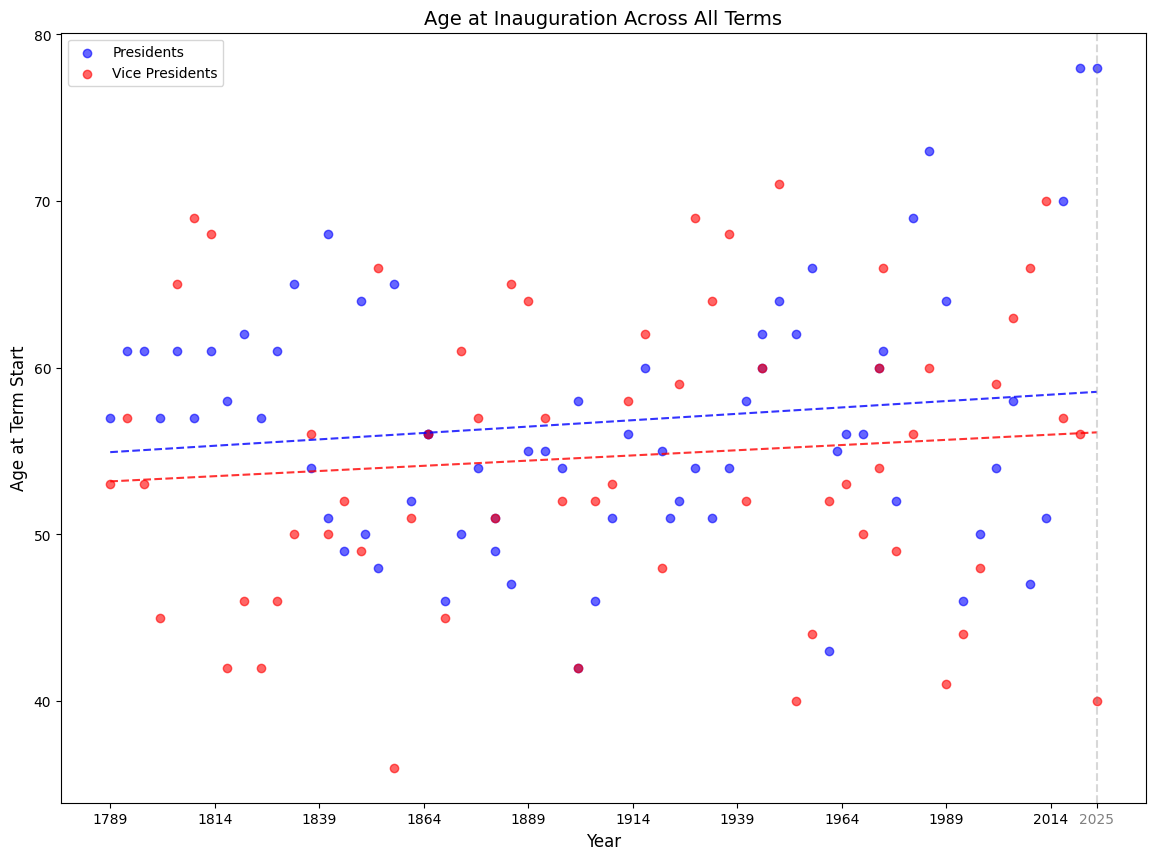


Presidents:
Average age at inauguration: 56.74 years
Median age at inauguration: 56.00 years
Age trend slope: 0.0153 years/year (1.53 years per century)

Vice Presidents:
Average age at inauguration: 54.68 years
Median age at inauguration: 53.50 years
Age trend slope: 0.0125 years/year (1.25 years per century)


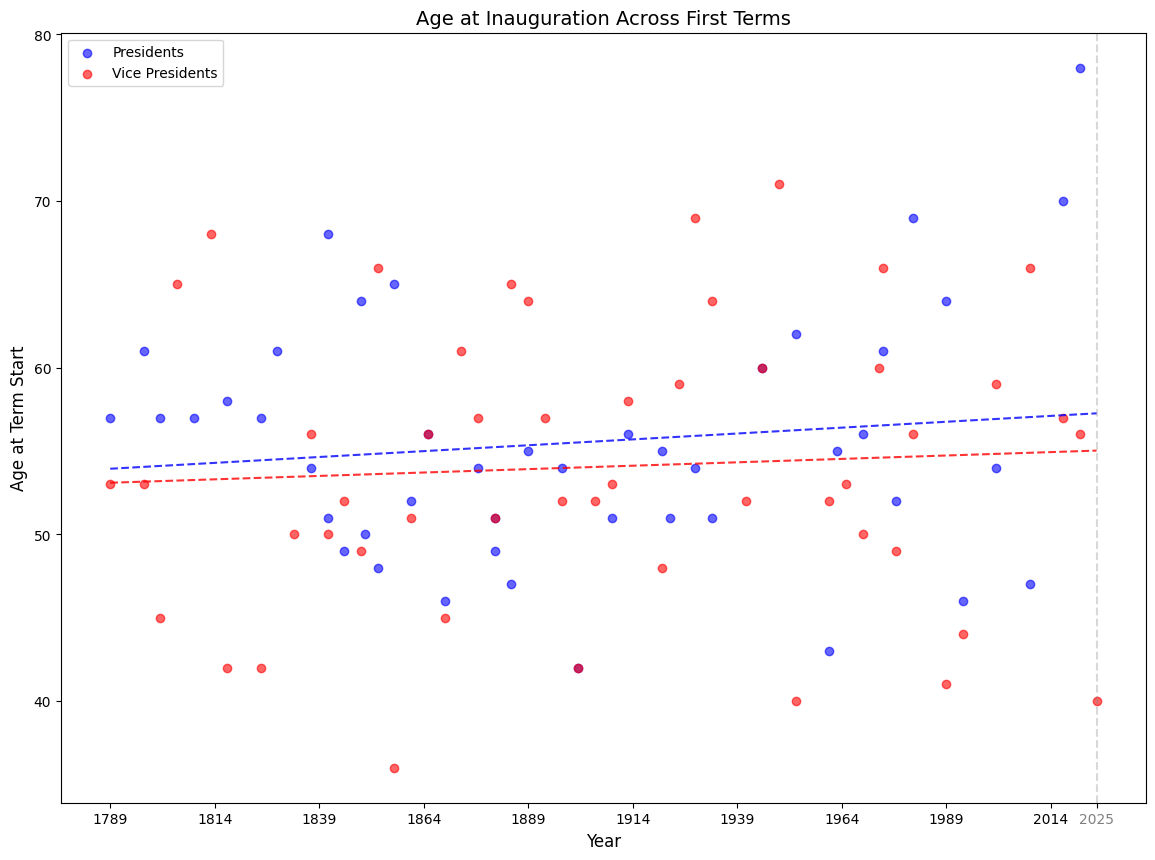


Presidents:
Average age at inauguration: 55.51 years
Median age at inauguration: 55.00 years
Age trend slope: 0.0141 years/year (1.41 years per century)

Vice Presidents:
Average age at inauguration: 54.06 years
Median age at inauguration: 53.00 years
Age trend slope: 0.0082 years/year (0.82 years per century)


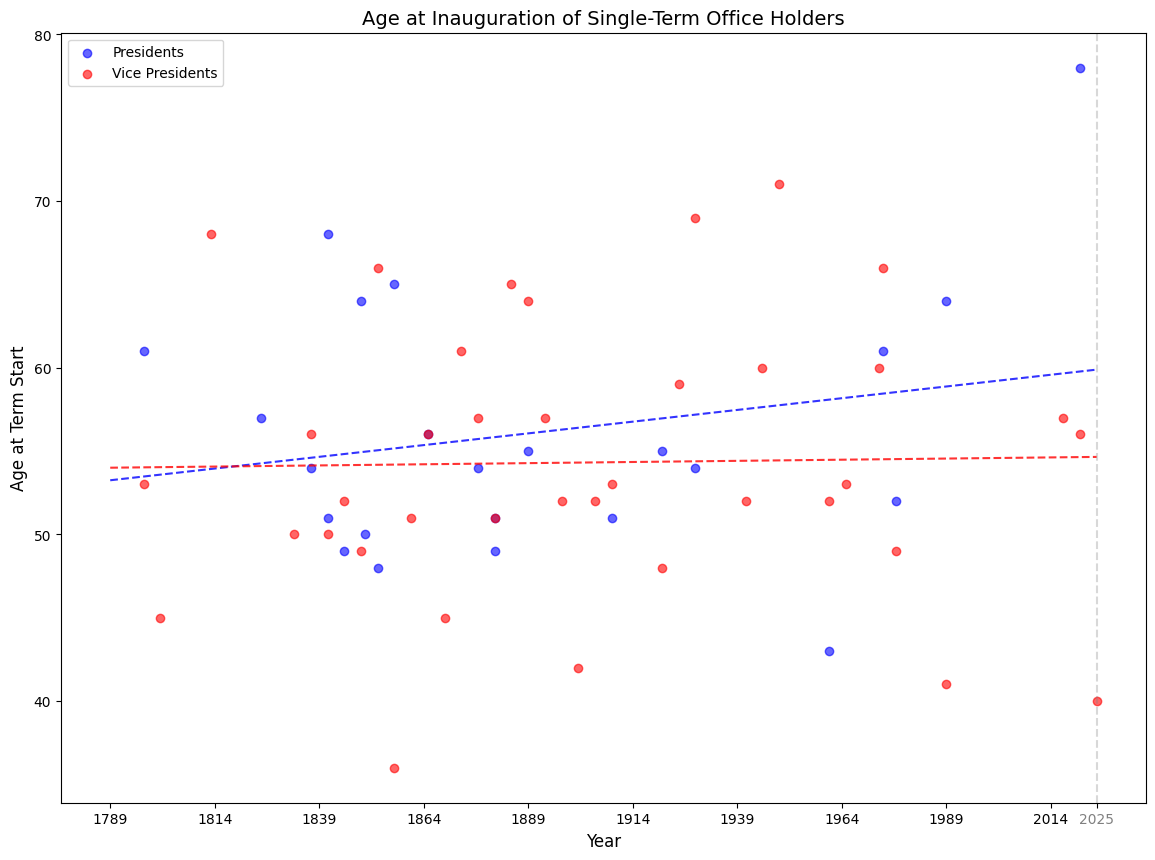


Presidents:
Average age at inauguration: 56.09 years
Median age at inauguration: 54.00 years
Age trend slope: 0.0281 years/year (2.81 years per century)

Vice Presidents:
Average age at inauguration: 54.32 years
Median age at inauguration: 53.00 years
Age trend slope: 0.0027 years/year (0.27 years per century)


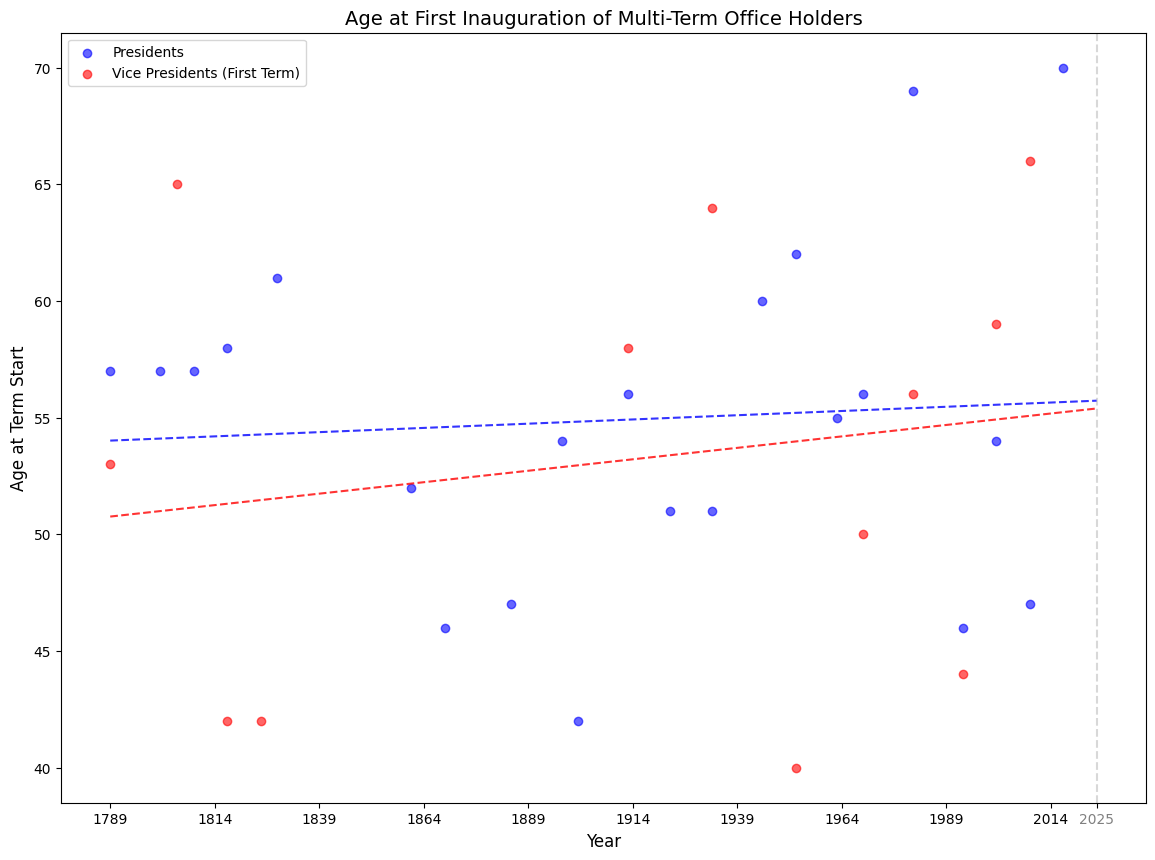


Presidents:
Average age at inauguration: 54.91 years
Median age at inauguration: 55.50 years
Age trend slope: 0.0072 years/year (0.72 years per century)

Vice Presidents (First Term):
Average age at inauguration: 53.25 years
Median age at inauguration: 54.50 years
Age trend slope: 0.0196 years/year (1.96 years per century)


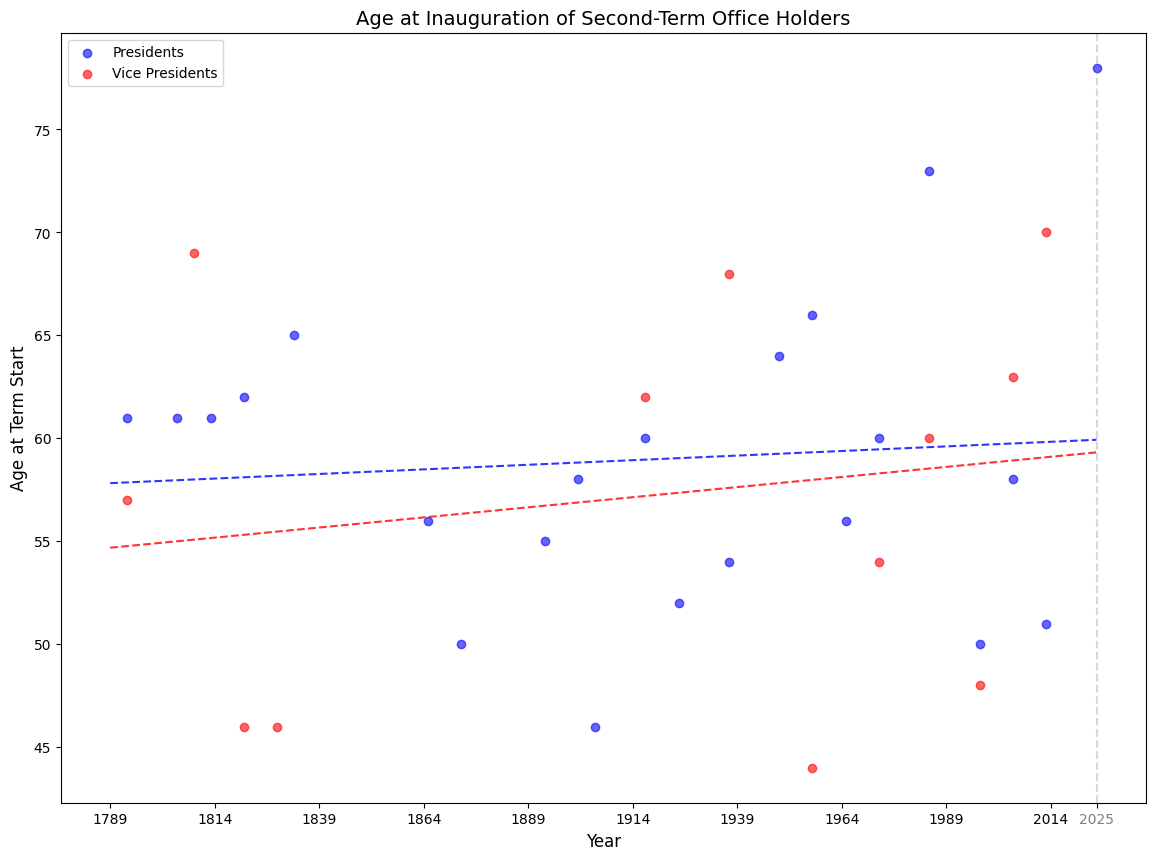


Presidents:
Average age at inauguration: 58.95 years
Median age at inauguration: 59.00 years
Age trend slope: 0.0089 years/year (0.89 years per century)

Vice Presidents:
Average age at inauguration: 57.25 years
Median age at inauguration: 58.50 years
Age trend slope: 0.0196 years/year (1.96 years per century)


In [14]:
def analyze_age_trend(df1, df2, title, label1, label2):
    """Analyze and visualize age trends for two datasets.
    
    Args:
        df1 (pd.DataFrame): First dataset for comparison
        df2 (pd.DataFrame): Second dataset for comparison
        title (str): Plot title
        label1 (str): Label for first dataset
        label2 (str): Label for second dataset
    
    Returns:
        tuple: Regression line slopes for both datasets
    """
    # Create figure
    plt.figure(figsize=(14, 10))
    
    # Calculate regression lines
    slope1, intercept1, _, _, _ = linregress(df1['start_term'].dt.year, df1['age_start'])
    slope2, intercept2, _, _, _ = linregress(df2['start_term'].dt.year, df2['age_start'])
    
    # Create years array for trend lines and ticks
    years = np.array([1789, 2025])  # Current year
    line1 = slope1 * years + intercept1
    line2 = slope2 * years + intercept2
    
    # Plot data points and trend lines
    plt.scatter(df1['start_term'].dt.year, df1['age_start'], 
                alpha=0.6, label=label1, color='blue')
    plt.scatter(df2['start_term'].dt.year, df2['age_start'], 
                alpha=0.6, label=label2, color='red')
    
    # Set x-axis ticks every 25 years from 1789 to 2025
    xticks = list(np.arange(1789, 2025, 25)) + [2025]  # Ensure 2025 is included
    plt.xticks(xticks)
    
    # Style the x-axis tick labels, making 2025 gray
    ax = plt.gca()
    tick_labels = ax.get_xticklabels()
    for label in tick_labels:
        if label.get_text() == '2025':
            label.set_color('gray')
    
    # Add faint vertical line at 2025 to show end of data
    plt.axvline(x=2025, color='gray', linestyle='--', alpha=0.3)
    
    plt.plot(years, line1, 'b--', alpha=0.8)
    plt.plot(years, line2, 'r--', alpha=0.8)
    
    plt.title(title)
    plt.xlabel('Year')
    plt.ylabel('Age at Term Start')
    plt.legend()
    plt.show()
    
    return slope1, slope2

def print_stats(name, df, slope=None):
    """Print age statistics and trend slope.
    
    Args:
        name (str): Name of the dataset
        df (pd.DataFrame): DataFrame containing term data
        slope (float, optional): Age trend slope (years per year)
    """
    print(f"\n{name}:")
    if 'age_start' in df.columns:
        # Calculate average age and median age
        avg_age = df['age_start'].mean()
        med_age = df['age_start'].median()
        print(f"Average age at inauguration: {avg_age:.2f} years")
        print(f"Median age at inauguration: {med_age:.2f} years")
        if slope is not None:
            print(f"Age trend slope: {slope:.4f} years/year ({slope*100:.2f} years per century)")
    else:
        print("Age data not available.")

# Generate plots for each comparison
print("Age Trends Analysis:")

# Plot configurations
plot_configs = [
    (presidents, vice_presidents, 'Age at Inauguration Across All Terms',
     'Presidents', 'Vice Presidents'),
    (first_term_presidents, first_term_vice_presidents, 'Age at Inauguration Across First Terms',
     'Presidents', 'Vice Presidents'),
    (single_term_presidents, single_term_vice_presidents, 'Age at Inauguration of Single-Term Office Holders',
     'Presidents', 'Vice Presidents'),
    (first_multi_term_presidents, first_multi_term_vice_presidents, 'Age at First Inauguration of Multi-Term Office Holders',
     'Presidents', 'Vice Presidents (First Term)'),
    (second_term_presidents, second_term_vice_presidents, 'Age at Inauguration of Second-Term Office Holders',
     'Presidents', 'Vice Presidents')
]

# Generate plots and analyze trends
for df1, df2, title, label1, label2 in plot_configs:
    # First analyze the age trends
    slope1, slope2 = analyze_age_trend(df1, df2, title, label1, label2)
    
    # Then print the statistics with the calculated slopes
    print_stats(label1, df1, slope1)
    print_stats(label2, df2, slope2)

## Term Completion Analysis
This section examines term completion patterns from 1789 to present across four key comparisons:

1. **All Terms**: Overall completion rates for presidential and vice-presidential terms

2. **First Terms**: Completion patterns for first-time officeholders vs subsequent terms

3. **Single vs Multi-Term**: Comparison of completion rates between single and multiple-term holders

4. **Second Terms**: Analysis of completion patterns in second terms

Term classifications:
- Complete: ≥ 3.9 years
- Partial: 2-3.9 years
- Early termination: <2 years

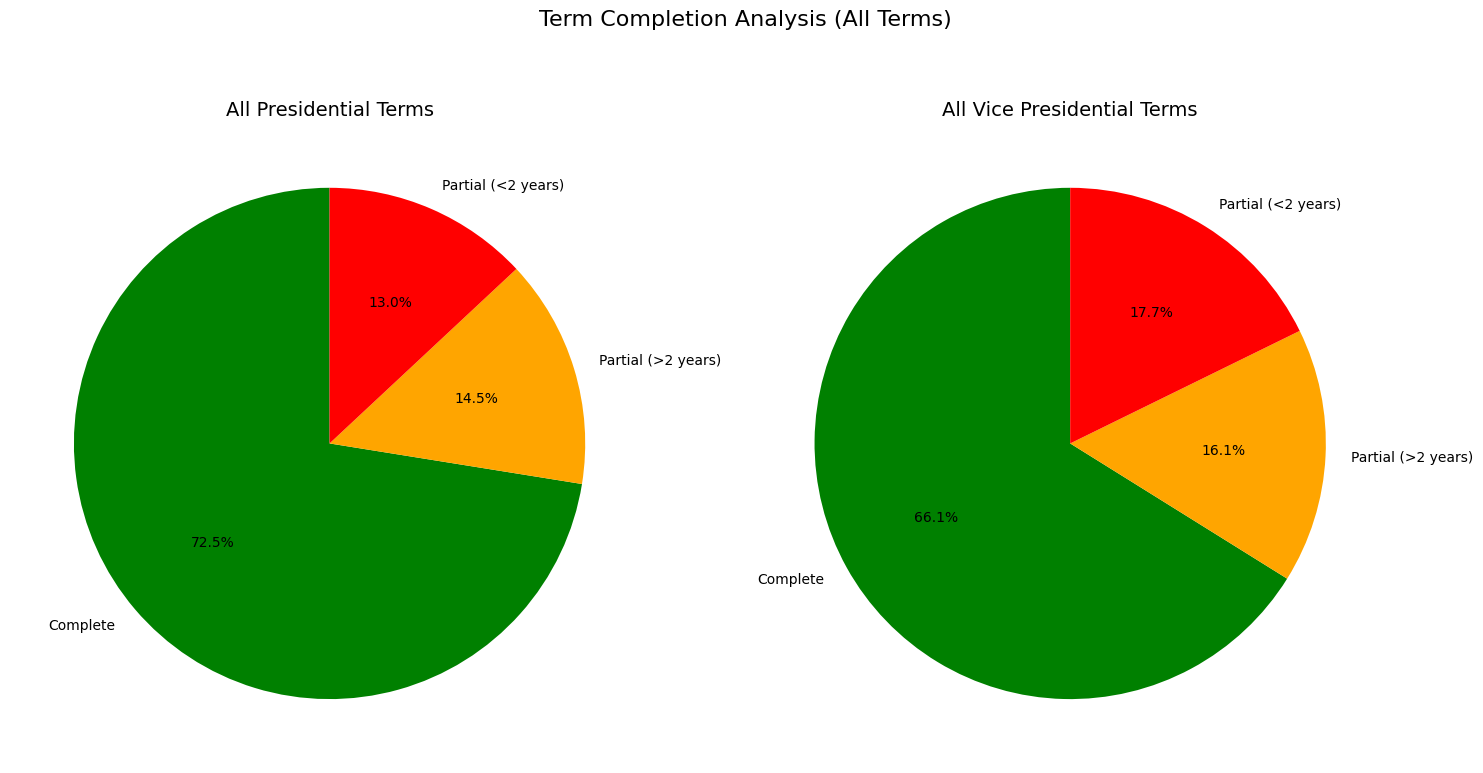


Completion Analysis:

All Presidential Terms:

All Presidential Terms:
Average age at inauguration: 56.74 years
Median age at inauguration: 56.00 years

All Vice Presidential Terms:

All Vice Presidential Terms:
Average age at inauguration: 54.68 years
Median age at inauguration: 53.50 years


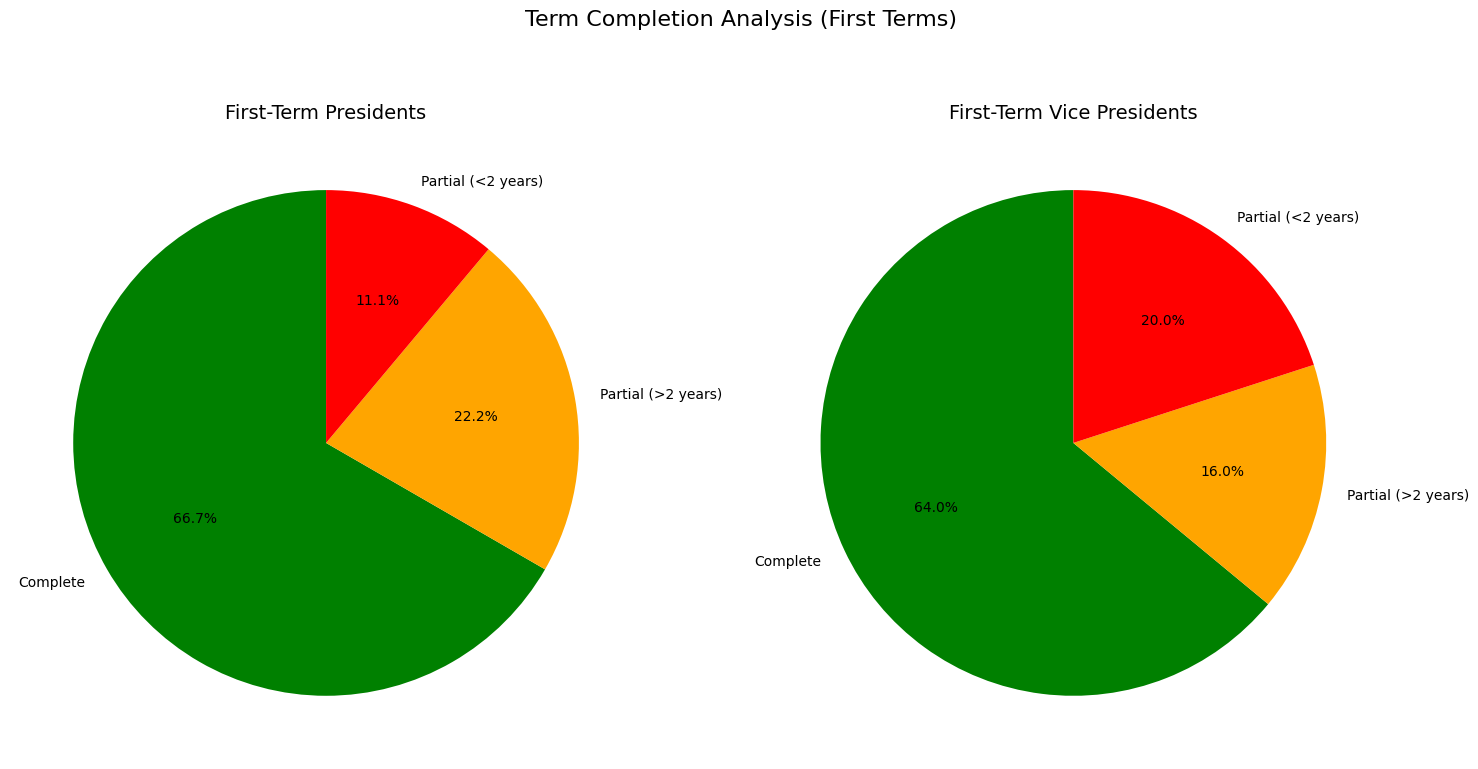


Completion Analysis:

First-Term Presidents:

First-Term Presidents:
Average age at inauguration: 55.51 years
Median age at inauguration: 55.00 years

First-Term Vice Presidents:

First-Term Vice Presidents:
Average age at inauguration: 54.06 years
Median age at inauguration: 53.00 years


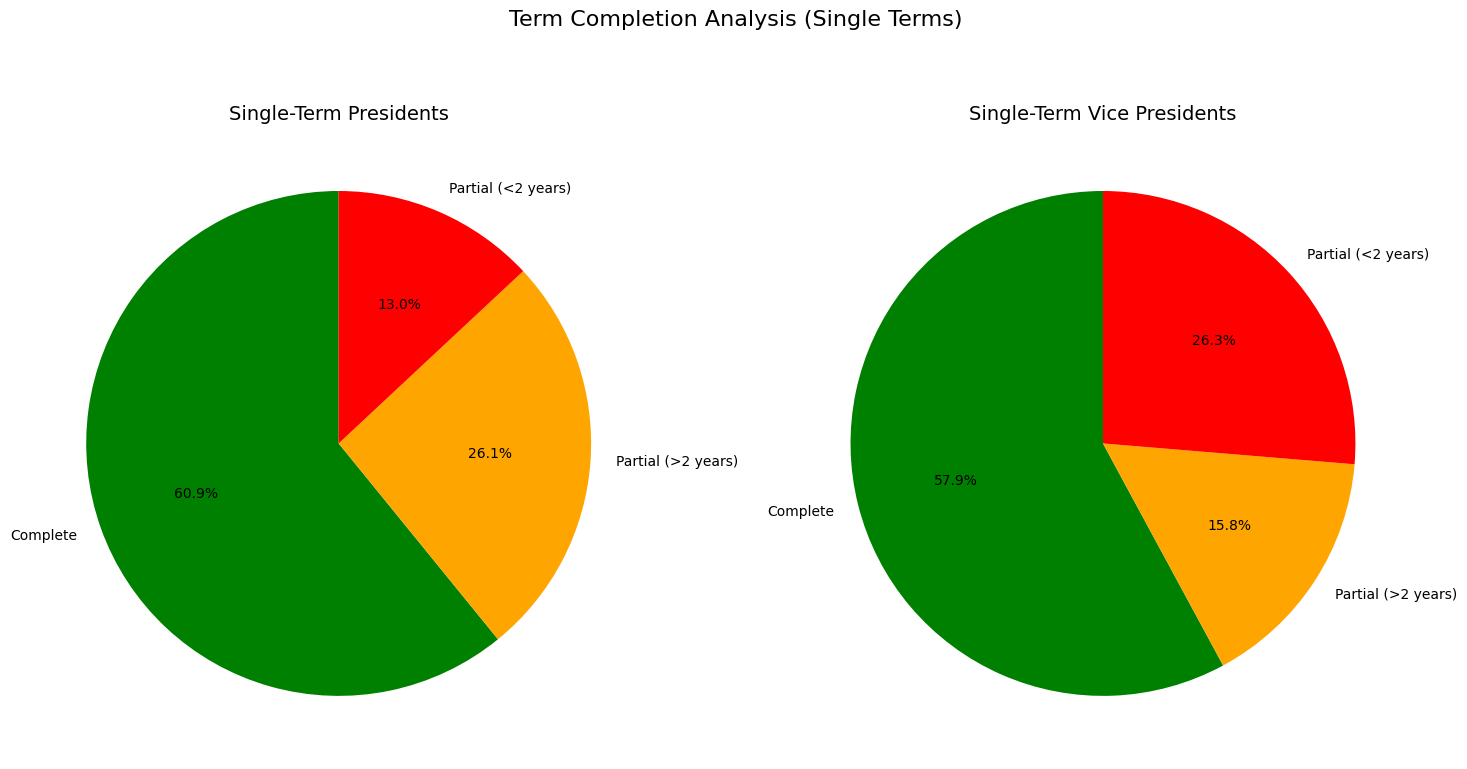


Completion Analysis:

Single-Term Presidents:

Single-Term Presidents:
Average age at inauguration: 56.09 years
Median age at inauguration: 54.00 years

Single-Term Vice Presidents:

Single-Term Vice Presidents:
Average age at inauguration: 54.32 years
Median age at inauguration: 53.00 years


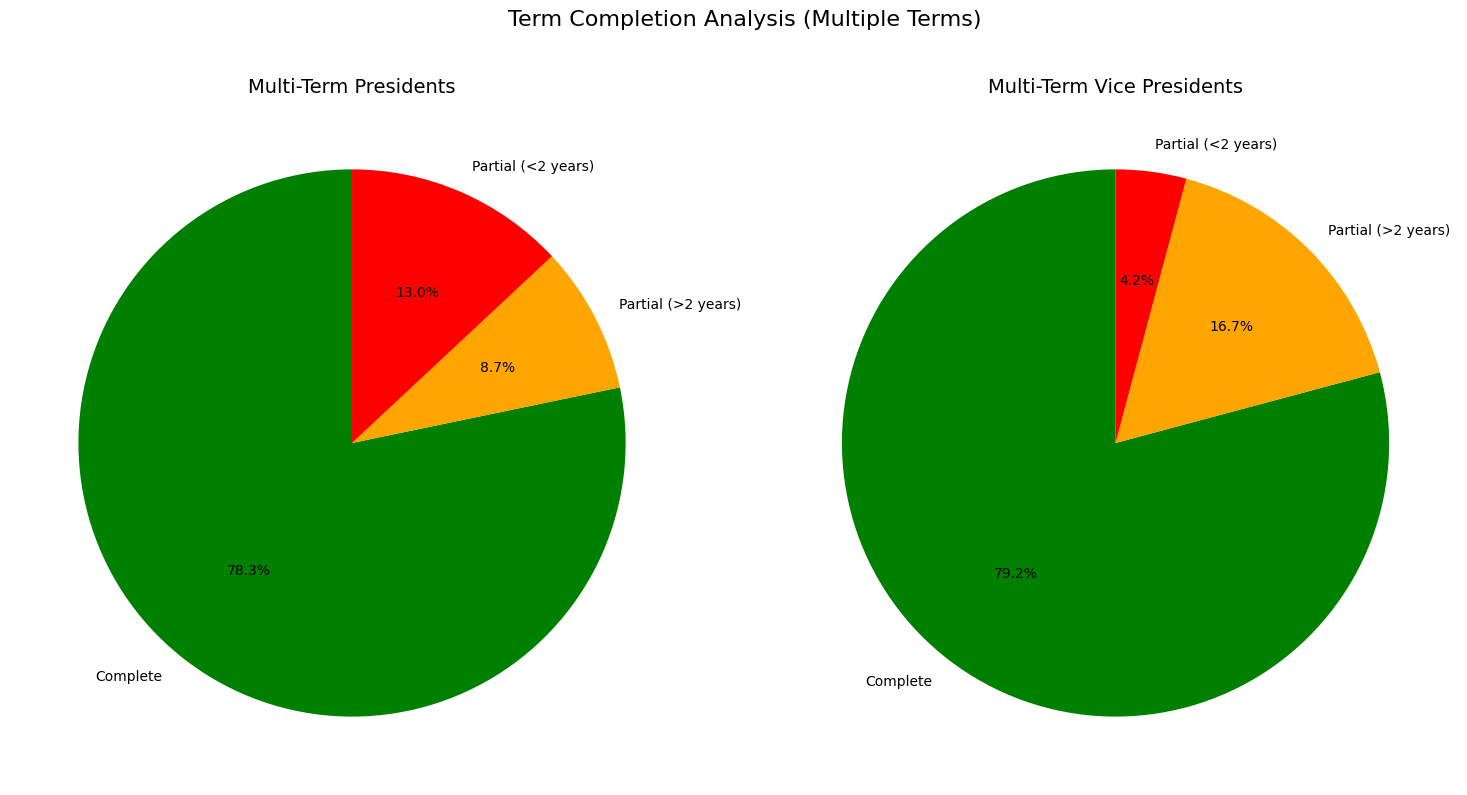


Completion Analysis:

Multi-Term Presidents:

Multi-Term Presidents:
Average age at inauguration: 57.07 years
Median age at inauguration: 57.00 years

Multi-Term Vice Presidents:

Multi-Term Vice Presidents:
Average age at inauguration: 55.25 years
Median age at inauguration: 56.50 years


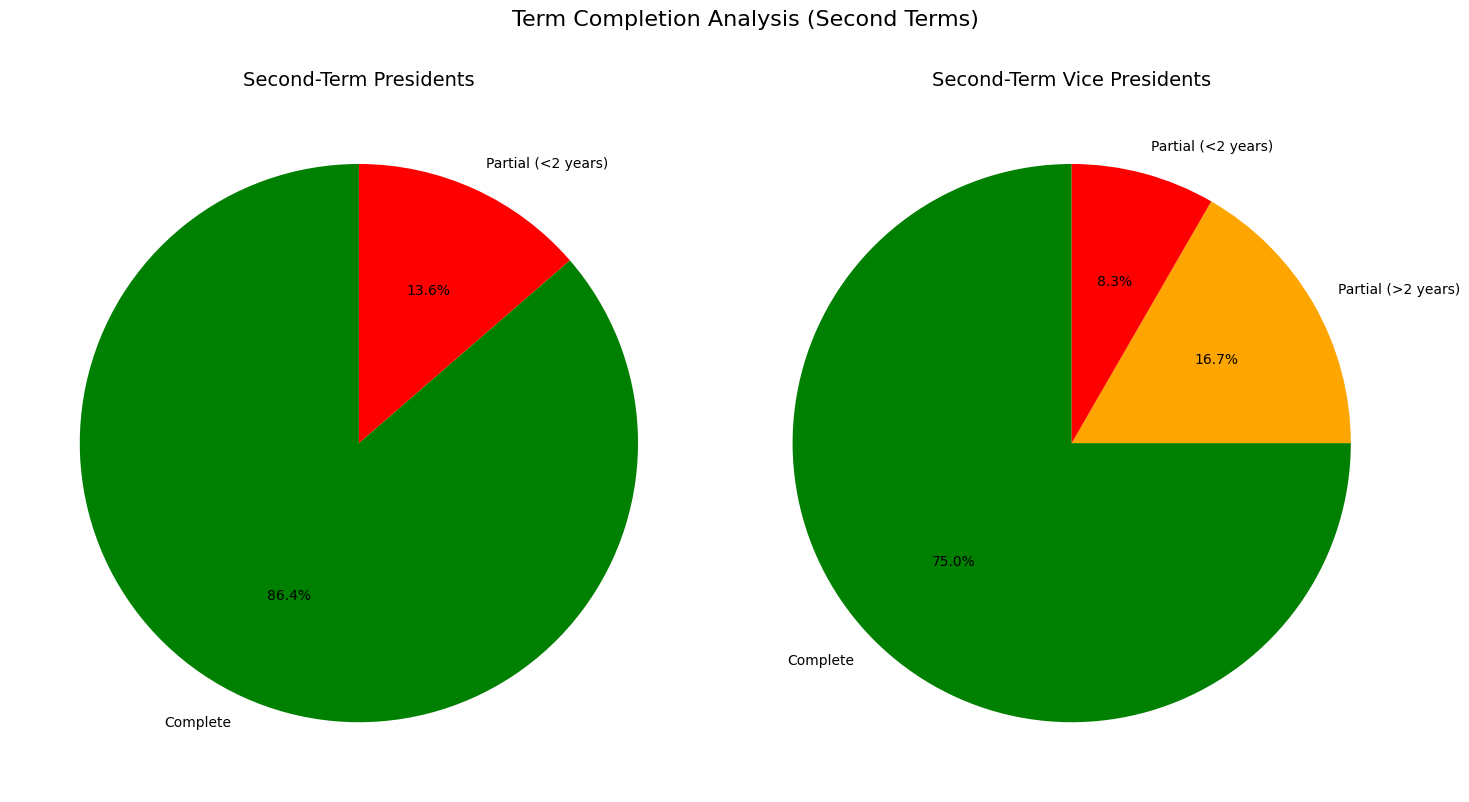


Completion Analysis:

Second-Term Presidents:

Second-Term Presidents:
Average age at inauguration: 58.95 years
Median age at inauguration: 59.00 years

Second-Term Vice Presidents:

Second-Term Vice Presidents:
Average age at inauguration: 57.25 years
Median age at inauguration: 58.50 years


In [15]:
# Calculate term length in years and completion status for all dataframes
def calculate_term_details(df):
    """Calculate term length in years and completion status.
    
    Args:
        df (pd.DataFrame): DataFrame containing term data with total_duration_years column
    
    Returns:
        pd.DataFrame: DataFrame with completion status added
    """
    # Ensure total_duration_years is numeric
    df['total_duration_years'] = pd.to_numeric(df['total_duration_years'], errors='coerce')
    
    # Define conditions for term completion status
    conditions = [
        (df['total_duration_years'] >= 3.9),
        (df['total_duration_years'] >= 2) & (df['total_duration_years'] < 3.9),
        (df['total_duration_years'] < 2)
    ]
    choices = ['Complete', 'Partial (>2 years)', 'Partial (<2 years)']
    df['completion'] = np.select(conditions, choices, default='Unknown')
    
    return df

def plot_completion_analysis(df1, df2, title1, title2, combined_title):
    """Create pie charts and print statistics for two datasets.
    
    Args:
        df1, df2 (pd.DataFrame): DataFrames to compare
        title1, title2 (str): Titles for individual plots
        combined_title (str): Overall comparison title
    """
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))
    fig.suptitle(combined_title, fontsize=16, y=1.02)
    
    # Define colors and labels
    colors_dict = {
        'Complete': 'green',
        'Partial (>2 years)': 'orange',
        'Partial (<2 years)': 'red',
        'Unknown': 'grey'
    }
    ordered_labels = ['Complete', 'Partial (>2 years)', 'Partial (<2 years)', 'Unknown']
    
    # Plot first pie chart
    counts1 = df1['completion'].value_counts()
    labels1 = [l for l in ordered_labels if l in counts1.index]
    ax1.pie(counts1[labels1], labels=labels1, colors=[colors_dict[l] for l in labels1],
            autopct='%1.1f%%', startangle=90)
    ax1.set_title(title1)
    
    # Plot second pie chart
    counts2 = df2['completion'].value_counts()
    labels2 = [l for l in ordered_labels if l in counts2.index]
    ax2.pie(counts2[labels2], labels=labels2, colors=[colors_dict[l] for l in labels2],
            autopct='%1.1f%%', startangle=90)
    ax2.set_title(title2)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\nCompletion Analysis:")
    print(f"\n{title1}:")
    print_stats(title1, df1)
    print(f"\n{title2}:")
    print_stats(title2, df2)

# Calculate term length and completion status for all dataframes
dataframes = [
    ('presidents', presidents),
    ('vice_presidents', vice_presidents),
    ('first_term_presidents', first_term_presidents),
    ('first_term_vice_presidents', first_term_vice_presidents),
    ('single_term_presidents', single_term_presidents),
    ('single_term_vice_presidents', single_term_vice_presidents),
    ('multi_term_presidents', multi_term_presidents),
    ('multi_term_vice_presidents', multi_term_vice_presidents),
    ('second_term_presidents', second_term_presidents),
    ('second_term_vice_presidents', second_term_vice_presidents)
]

for name, df in dataframes:
    globals()[name] = calculate_term_details(df)

# Plot configurations
plot_configs = [
    (presidents, vice_presidents,
     'All Presidential Terms', 'All Vice Presidential Terms',
     'Term Completion Analysis (All Terms)'),
    
    (first_term_presidents, first_term_vice_presidents,
     'First-Term Presidents', 'First-Term Vice Presidents',
     'Term Completion Analysis (First Terms)'),
    
    (single_term_presidents, single_term_vice_presidents,
     'Single-Term Presidents', 'Single-Term Vice Presidents',
     'Term Completion Analysis (Single Terms)'),
    
    (multi_term_presidents, multi_term_vice_presidents,
     'Multi-Term Presidents', 'Multi-Term Vice Presidents',
     'Term Completion Analysis (Multiple Terms)'),
    
    (second_term_presidents, second_term_vice_presidents,
     'Second-Term Presidents', 'Second-Term Vice Presidents',
     'Term Completion Analysis (Second Terms)')
]

# Generate all plots with statistics
for df1, df2, title1, title2, combined_title in plot_configs:
    plot_completion_analysis(df1, df2, title1, title2, combined_title)

## Age and Term Completion Relationship
This section examines the relationship between starting age and term completion across three key aspects:

1. **Age Distribution**: Analysis of age patterns across complete and partial terms through swarm plots

2. **Term Type Analysis**: Comparison of age distributions between different term completion categories

3. **Statistical Measures**: Calculation of age statistics (mean, range) for each completion status

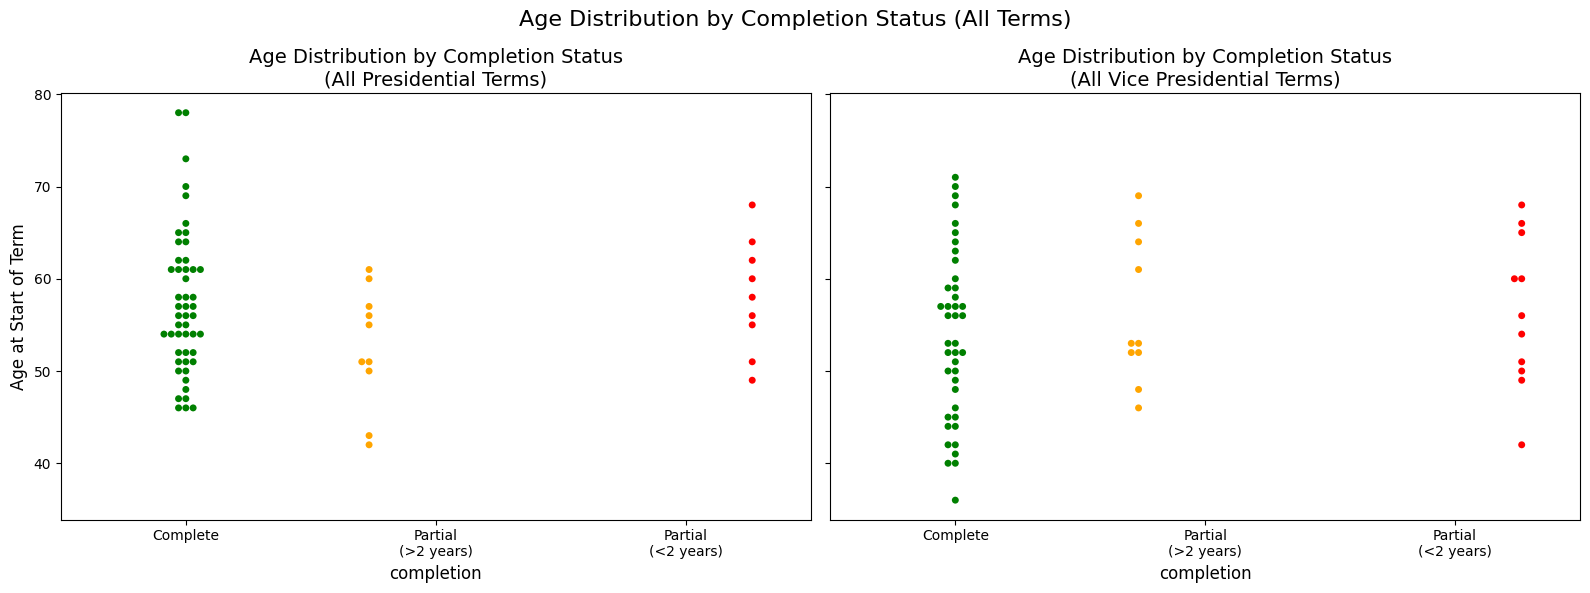


Age Distribution Analysis:

Age Distribution by Completion Status
(All Presidential Terms):

Age Statistics by Completion Status:

Complete:
  Count: 50
  Average age: 57.3
  Age range: 46-78

Partial (>2 years):
  Count: 10
  Average age: 52.6
  Age range: 42-61

Partial (<2 years):
  Count: 9
  Average age: 58.1
  Age range: 49-68

Age Distribution by Completion Status
(All Vice Presidential Terms):

Age Statistics by Completion Status:

Complete:
  Count: 41
  Average age: 53.8
  Age range: 36-71

Partial (>2 years):
  Count: 10
  Average age: 56.4
  Age range: 46-69

Partial (<2 years):
  Count: 11
  Average age: 56.5
  Age range: 42-68


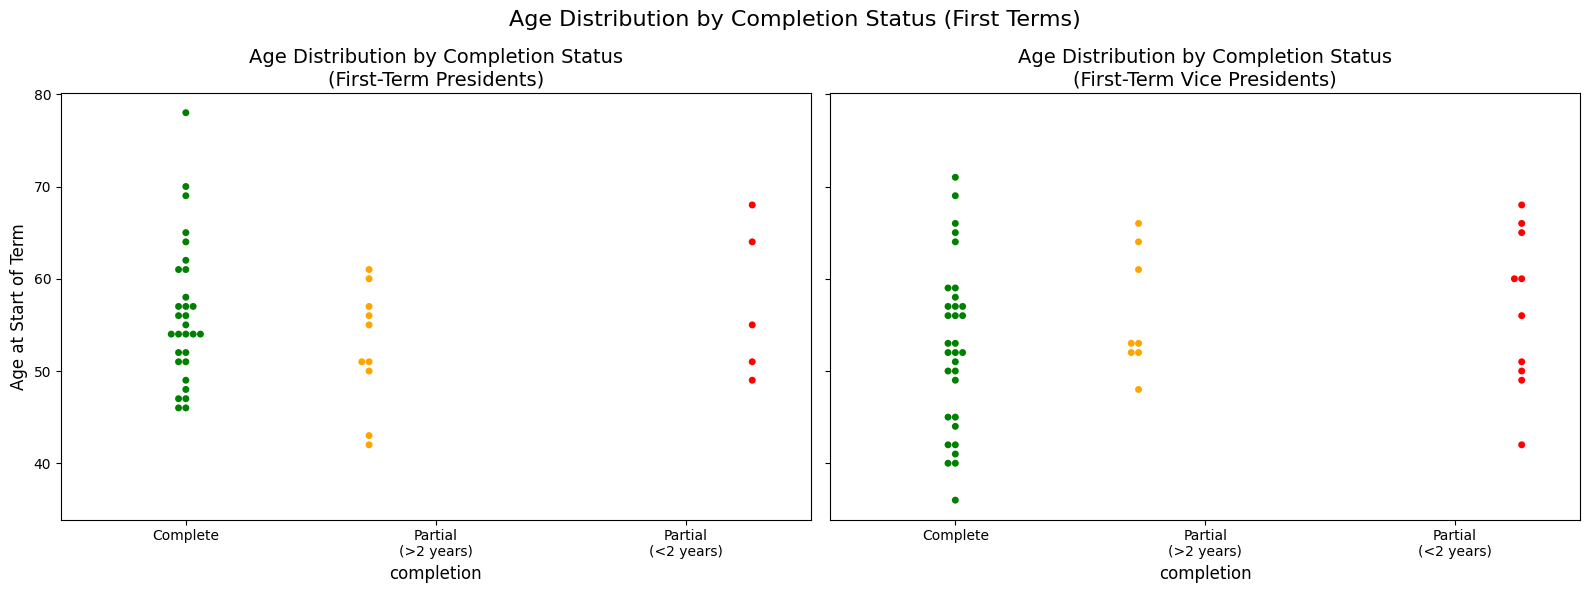


Age Distribution Analysis:

Age Distribution by Completion Status
(First-Term Presidents):

Age Statistics by Completion Status:

Complete:
  Count: 30
  Average age: 56.2
  Age range: 46-78

Partial (>2 years):
  Count: 10
  Average age: 52.6
  Age range: 42-61

Partial (<2 years):
  Count: 5
  Average age: 57.4
  Age range: 49-68

Age Distribution by Completion Status
(First-Term Vice Presidents):

Age Statistics by Completion Status:

Complete:
  Count: 32
  Average age: 52.7
  Age range: 36-71

Partial (>2 years):
  Count: 8
  Average age: 56.1
  Age range: 48-66

Partial (<2 years):
  Count: 10
  Average age: 56.7
  Age range: 42-68


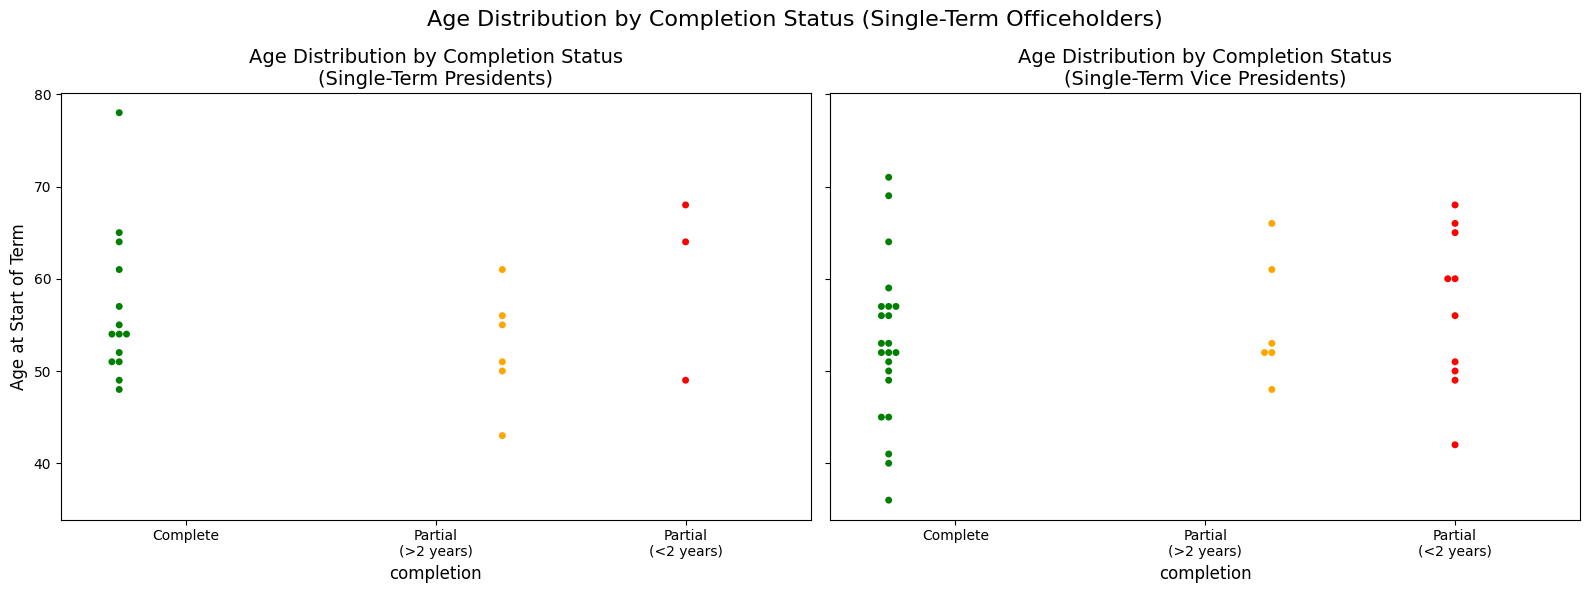


Age Distribution Analysis:

Age Distribution by Completion Status
(Single-Term Presidents):

Age Statistics by Completion Status:

Complete:
  Count: 14
  Average age: 56.6
  Age range: 48-78

Partial (>2 years):
  Count: 6
  Average age: 52.7
  Age range: 43-61

Partial (<2 years):
  Count: 3
  Average age: 60.3
  Age range: 49-68

Age Distribution by Completion Status
(Single-Term Vice Presidents):

Age Statistics by Completion Status:

Complete:
  Count: 22
  Average age: 53.0
  Age range: 36-71

Partial (>2 years):
  Count: 6
  Average age: 55.3
  Age range: 48-66

Partial (<2 years):
  Count: 10
  Average age: 56.7
  Age range: 42-68


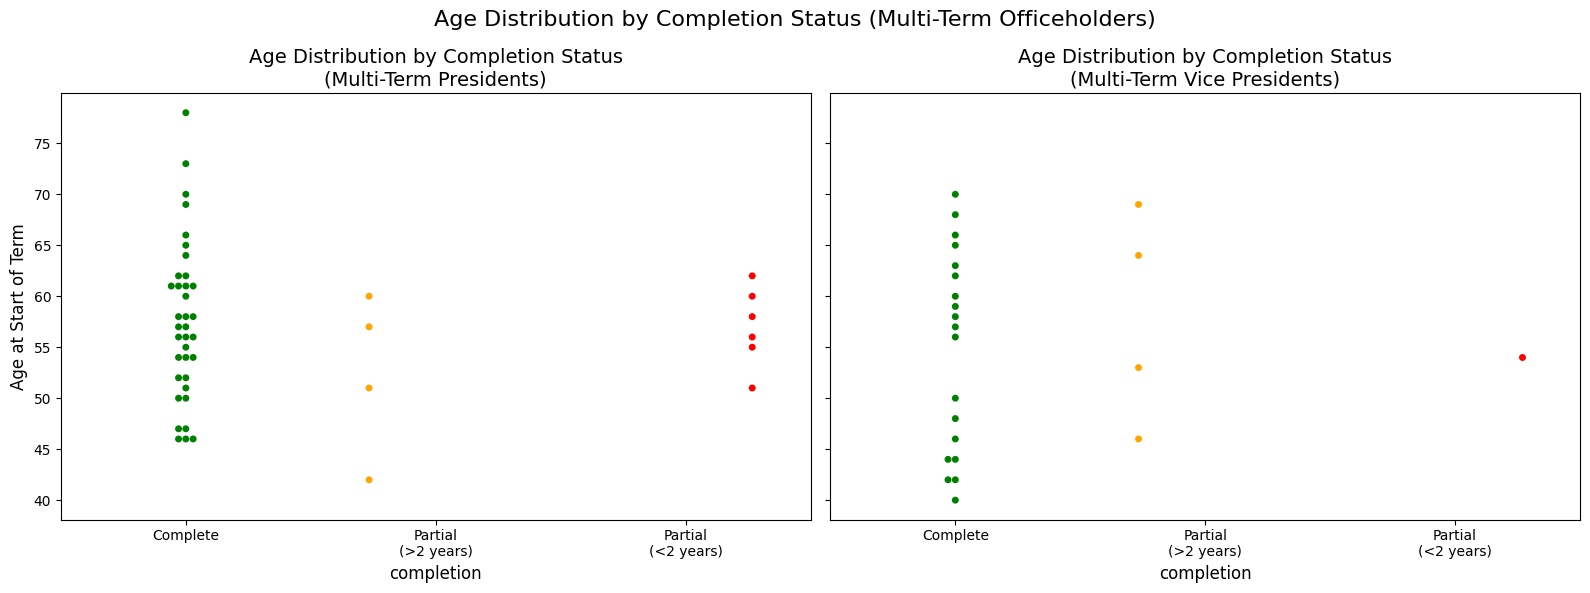


Age Distribution Analysis:

Age Distribution by Completion Status
(Multi-Term Presidents):

Age Statistics by Completion Status:

Complete:
  Count: 36
  Average age: 57.6
  Age range: 46-78

Partial (>2 years):
  Count: 4
  Average age: 52.5
  Age range: 42-60

Partial (<2 years):
  Count: 6
  Average age: 57.0
  Age range: 51-62

Age Distribution by Completion Status
(Multi-Term Vice Presidents):

Age Statistics by Completion Status:

Complete:
  Count: 19
  Average age: 54.7
  Age range: 40-70

Partial (>2 years):
  Count: 4
  Average age: 58.0
  Age range: 46-69

Partial (<2 years):
  Count: 1
  Average age: 54.0
  Age range: 54-54


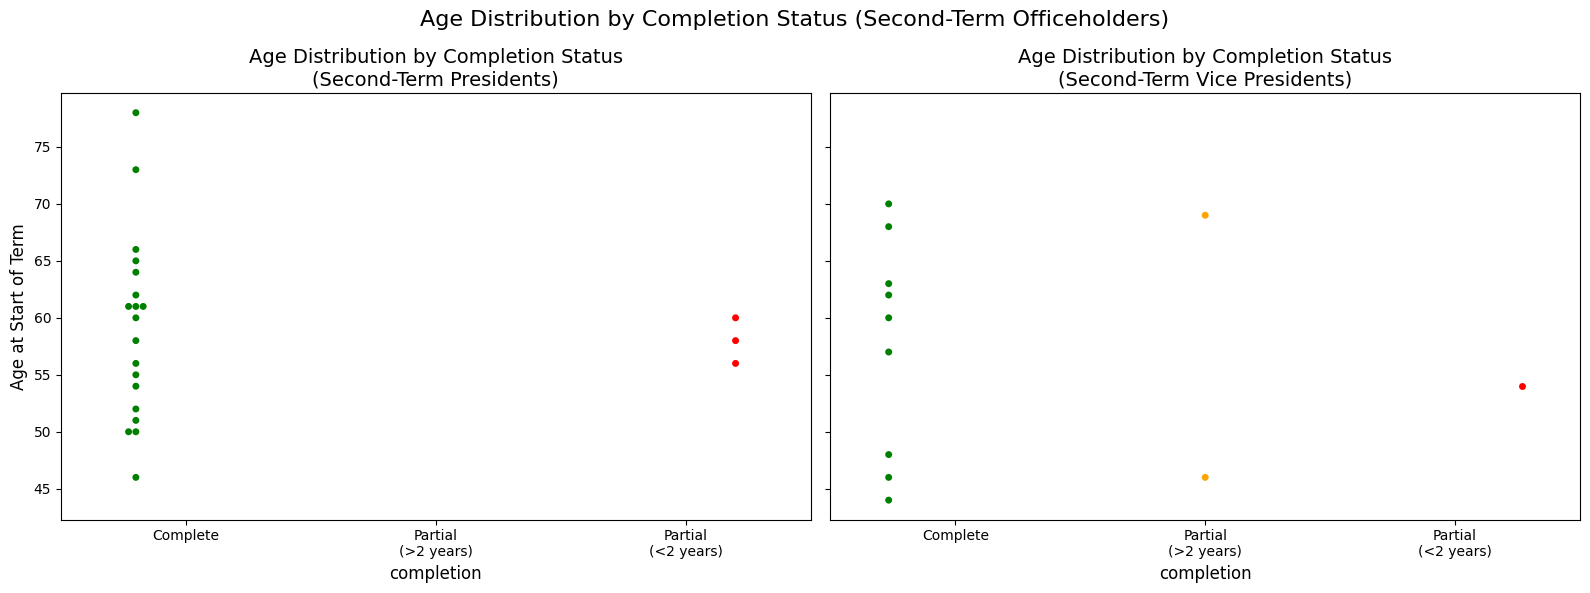


Age Distribution Analysis:

Age Distribution by Completion Status
(Second-Term Presidents):

Age Statistics by Completion Status:

Complete:
  Count: 19
  Average age: 59.1
  Age range: 46-78

Partial (<2 years):
  Count: 3
  Average age: 58.0
  Age range: 56-60

Age Distribution by Completion Status
(Second-Term Vice Presidents):

Age Statistics by Completion Status:

Complete:
  Count: 9
  Average age: 57.6
  Age range: 44-70

Partial (>2 years):
  Count: 2
  Average age: 57.5
  Age range: 46-69

Partial (<2 years):
  Count: 1
  Average age: 54.0
  Age range: 54-54

Age and Completion Analysis:

All Presidential Terms:
Overall Statistics:
Total terms: 69

Age Statistics by Completion Status:

Complete:
  Count: 50
  Average age: 57.3
  Age range: 46-78

Partial (>2 years):
  Count: 10
  Average age: 52.6
  Age range: 42-61

Partial (<2 years):
  Count: 9
  Average age: 58.1
  Age range: 49-68

Completion Rates by Age Group:

50-60:
  Total terms: 35
  Complete terms: 24 (68.6%)

Ove

In [16]:
# Create combined plots for each category of age distribution by completion status

def plot_combined_age_completion(df1, df2, title1, title2, combined_title):
    """Create combined swarm plot of age distribution by completion status.
    
    Args:
        df1 (pd.DataFrame): First dataset for comparison
        df2 (pd.DataFrame): Second dataset for comparison
        title1 (str): Title for first subplot
        title2 (str): Title for second subplot
        combined_title (str): Title for overall figure
    """
    # Create swarm plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    
    # Plot settings
    completion_order = ['Complete', 'Partial (>2 years)', 'Partial (<2 years)']
    completion_colors = {
        'Complete': 'green',
        'Partial (>2 years)': 'orange',
        'Partial (<2 years)': 'red'
    }
    
    # First subplot
    sns.swarmplot(
        x='completion',
        y='age_start',
        data=df1,
        hue='completion',
        dodge=True,
        order=completion_order,
        palette=completion_colors,
        ax=axes[0],
        legend=False
    )
    axes[0].set_title(title1)
    axes[0].set_xticks(range(3))
    axes[0].set_xticklabels(['Complete', 'Partial\n(>2 years)', 'Partial\n(<2 years)'])
    axes[0].set_ylabel('Age at Start of Term')
    
    # Second subplot
    sns.swarmplot(
        x='completion',
        y='age_start',
        data=df2,
        hue='completion',
        dodge=True,
        order=completion_order,
        palette=completion_colors,
        ax=axes[1],
        legend=False
    )
    axes[1].set_title(title2)
    axes[1].set_xticks(range(3))
    axes[1].set_xticklabels(['Complete', 'Partial\n(>2 years)', 'Partial\n(<2 years)'])
    
    fig.suptitle(combined_title, size=16)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\nAge Distribution Analysis:")
    print(f"\n{title1}:")
    if 'completion' in df1.columns and 'age_start' in df1.columns:
        # Age statistics by completion status
        print("\nAge Statistics by Completion Status:")
        for status in completion_order:
            subset = df1[df1['completion'] == status]
            if len(subset) > 0:
                avg_age = subset['age_start'].mean()
                min_age = subset['age_start'].min()
                max_age = subset['age_start'].max()
                print(f"\n{status}:")
                print(f"  Count: {len(subset)}")
                print(f"  Average age: {avg_age:.1f}")
                print(f"  Age range: {min_age:.0f}-{max_age:.0f}")
    
    print(f"\n{title2}:")
    if 'completion' in df2.columns and 'age_start' in df2.columns:
        # Age statistics by completion status
        print("\nAge Statistics by Completion Status:")
        for status in completion_order:
            subset = df2[df2['completion'] == status]
            if len(subset) > 0:
                avg_age = subset['age_start'].mean()
                min_age = subset['age_start'].min()
                max_age = subset['age_start'].max()
                print(f"\n{status}:")
                print(f"  Count: {len(subset)}")
                print(f"  Average age: {avg_age:.1f}")
                print(f"  Age range: {min_age:.0f}-{max_age:.0f}")

def print_stats(name, df):
    """Print statistical summary of age and completion relationships"""
    print(f"\n{name}:")
    if 'completion' in df.columns and 'age_start' in df.columns:
        # 1. Overall stats
        print("Overall Statistics:")
        print(f"Total terms: {len(df)}")
        
        # 2. Age statistics by completion status
        print("\nAge Statistics by Completion Status:")
        for status in ['Complete', 'Partial (>2 years)', 'Partial (<2 years)']:
            subset = df[df['completion'] == status]
            if len(subset) > 0:
                avg_age = subset['age_start'].mean()
                min_age = subset['age_start'].min()
                max_age = subset['age_start'].max()
                print(f"\n{status}:")
                print(f"  Count: {len(subset)}")
                print(f"  Average age: {avg_age:.1f}")
                print(f"  Age range: {min_age:.0f}-{max_age:.0f}")
        
        # 3. Completion rates by age group
        print("\nCompletion Rates by Age Group:")
        df['age_group'] = pd.cut(df['age_start'], 
                                bins=[0, 50, 60, 100],
                                labels=['Under 50', '50-60', 'Over 60'])
        
        for age_group in df['age_group'].unique():
            group_df = df[df['age_group'] == age_group]
            complete_count = (group_df['completion'] == 'Complete').sum()
            group_total = len(group_df)
            if group_total > 0:
                complete_rate = complete_count / group_total
                print(f"\n{age_group}:")
                print(f"  Total terms: {group_total}")
                print(f"  Complete terms: {complete_count} ({complete_rate:.1%})")
    else:
        print("Required data not available.")

# Configuration for plots
plot_configs = [
    (presidents, vice_presidents,
     'Age Distribution by Completion Status\n(All Presidential Terms)',
     'Age Distribution by Completion Status\n(All Vice Presidential Terms)',
     'Age Distribution by Completion Status (All Terms)'),
    
    (first_term_presidents, first_term_vice_presidents,
     'Age Distribution by Completion Status\n(First-Term Presidents)',
     'Age Distribution by Completion Status\n(First-Term Vice Presidents)',
     'Age Distribution by Completion Status (First Terms)'),
    
    (single_term_presidents, single_term_vice_presidents,
     'Age Distribution by Completion Status\n(Single-Term Presidents)',
     'Age Distribution by Completion Status\n(Single-Term Vice Presidents)',
     'Age Distribution by Completion Status (Single-Term Officeholders)'),
    
    (multi_term_presidents, multi_term_vice_presidents,
     'Age Distribution by Completion Status\n(Multi-Term Presidents)',
     'Age Distribution by Completion Status\n(Multi-Term Vice Presidents)',
     'Age Distribution by Completion Status (Multi-Term Officeholders)'),
    
    (second_term_presidents, second_term_vice_presidents,
     'Age Distribution by Completion Status\n(Second-Term Presidents)',
     'Age Distribution by Completion Status\n(Second-Term Vice Presidents)',
     'Age Distribution by Completion Status (Second-Term Officeholders)')
]

# Generate all plots with statistics
for df1, df2, title1, title2, combined_title in plot_configs:
    plot_combined_age_completion(df1, df2, title1, title2, combined_title)

# Create lists of plots and categories
categories = [
    (presidents, "All Presidential Terms"),
    (vice_presidents, "All Vice Presidential Terms"),
    (first_term_presidents, "First-Term Presidents"),
    (first_term_vice_presidents, "First-Term Vice Presidents"),
    (single_term_presidents, "Single-Term Presidents"),
    (single_term_vice_presidents, "Single-Term Vice Presidents"),
    (multi_term_presidents, "Multi-Term Presidents"),
    (multi_term_vice_presidents, "Multi-Term Vice Presidents"),
    (second_term_presidents, "Second-Term Presidents"),
    (second_term_vice_presidents, "Second-Term Vice Presidents")
]

# Print statistics for all categories
print("\nAge and Completion Analysis:")
for df, title in categories:
    print_stats(title, df)

## Predicting Term Completion with Logistic Regression
This section focuses on first-term officeholders for better prediction accuracy.
 The implementation includes:

1. **Data Preparation**
   - Filter first-term data with completion categories

2. **Model Training**
   - Train logistic regression models for presidents and VPs
   - Split data into train/test sets with stratification

3. **Results Analysis**
   - Visualize probability curves with data distribution
   - Calculate accuracy and confusion matrices
   - Generate performance metrics

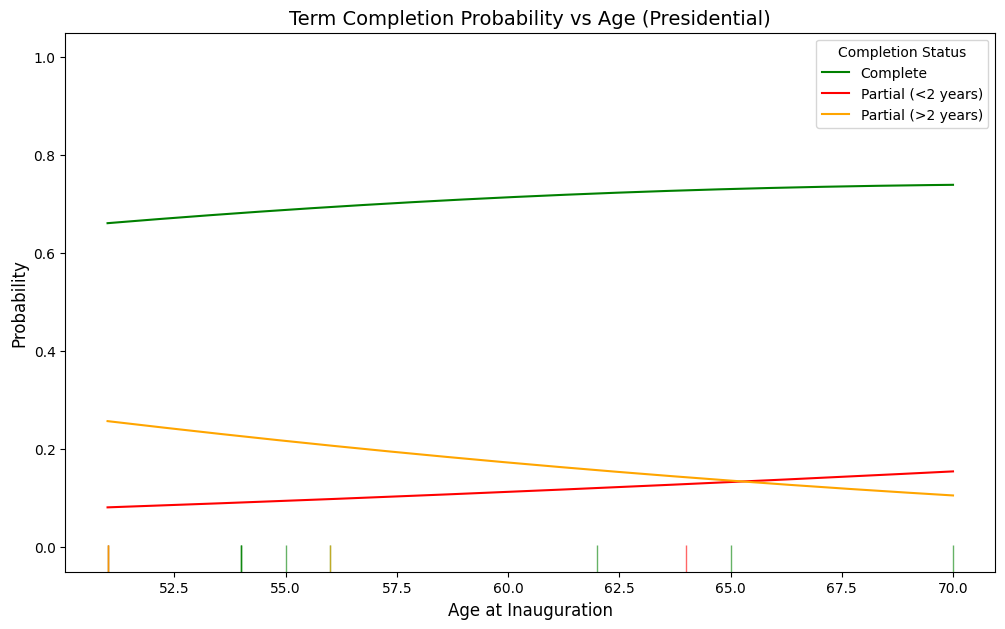


Results for Presidential Term Completion Prediction

Accuracy: 64.29%
Test cases: 14

Confusion Matrix:
                          Pred: Complete  Pred: Partial (<2 years)  \
True: Complete                         9                         0   
True: Partial (<2 years)               2                         0   
True: Partial (>2 years)               3                         0   

                          Pred: Partial (>2 years)  
True: Complete                                   0  
True: Partial (<2 years)                         0  
True: Partial (>2 years)                         0  

Detailed Metrics:
                    precision    recall  f1-score   support

          Complete       0.64      1.00      0.78         9
Partial (<2 years)       0.00      0.00      0.00         2
Partial (>2 years)       0.00      0.00      0.00         3

          accuracy                           0.64        14
         macro avg       0.21      0.33      0.26        14
      weighted avg   

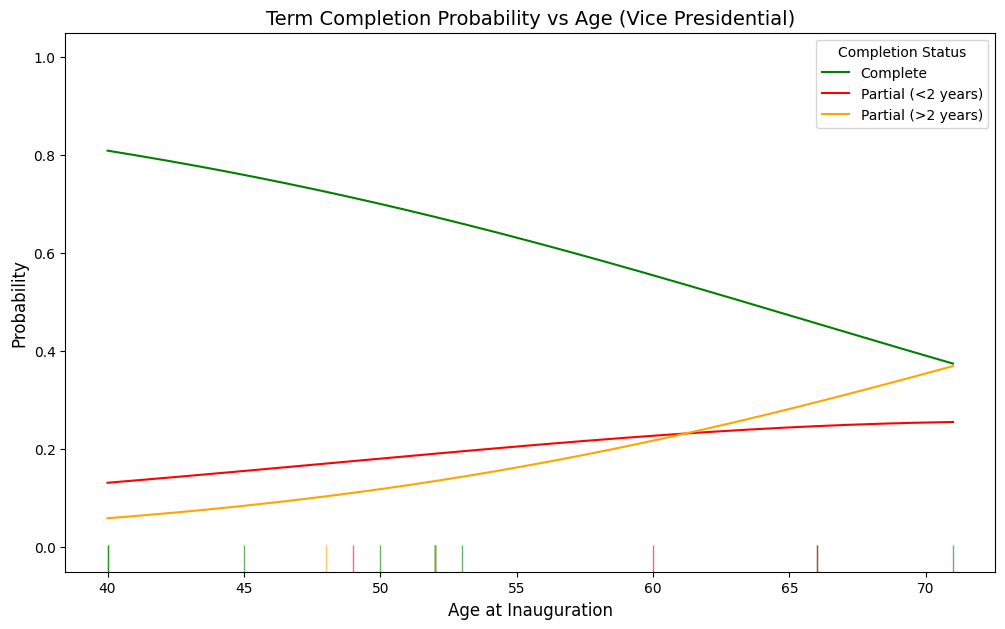


Results for Vice Presidential Term Completion Prediction

Accuracy: 66.67%
Test cases: 15

Confusion Matrix:
                          Pred: Complete  Pred: Partial (<2 years)  \
True: Complete                        10                         0   
True: Partial (<2 years)               3                         0   
True: Partial (>2 years)               2                         0   

                          Pred: Partial (>2 years)  
True: Complete                                   0  
True: Partial (<2 years)                         0  
True: Partial (>2 years)                         0  

Detailed Metrics:
                    precision    recall  f1-score   support

          Complete       0.67      1.00      0.80        10
Partial (<2 years)       0.00      0.00      0.00         3
Partial (>2 years)       0.00      0.00      0.00         2

          accuracy                           0.67        15
         macro avg       0.22      0.33      0.27        15
      weighted a

In [17]:
def prepare_data(df, valid_classes):
    """Prepare and encode data for model training."""
    df_filtered = df[df['completion'].isin(valid_classes)]
    X = df_filtered[['age_start']]
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(df_filtered['completion'])
    return X, y_encoded, label_encoder

def train_and_evaluate_model(X, y_encoded, label_encoder, role):
    """Train and evaluate logistic regression model."""
    if len(X) < 10 or len(np.unique(y_encoded)) < 2:
        print(f"Insufficient data for {role} model.")
        return
        
    # Split data with stratification
    y_counts = pd.Series(y_encoded).value_counts()
    stratify = y_encoded if len(y_counts) > 1 and y_counts.min() > 1 else None
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.3, random_state=42, stratify=stratify
    )
    
    # Train model
    model = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)
    
    # Convert encodings back to labels
    y_test_labels = label_encoder.inverse_transform(y_test)
    y_pred_labels = label_encoder.inverse_transform(y_pred)
    
    # Create results visualization
    plot_results(X_test, y_test, model, label_encoder, role)
    
    # Present detailed results
    present_results(X_test, y_test_labels, y_pred_labels, y_pred_proba, 
                   role, label_encoder.classes_)

def plot_results(X_test, y_test_encoded, model, encoder, role):
    """Plot logistic regression results."""
    plt.figure(figsize=(12, 7))
    
    colors = {'Complete': 'green', 
              'Partial (>2 years)': 'orange', 
              'Partial (<2 years)': 'red'}
    
    # Generate probability curves
    x_range = np.linspace(X_test['age_start'].min(), X_test['age_start'].max(), 300)
    x_df = pd.DataFrame(x_range.reshape(-1, 1), columns=['age_start'])
    y_proba = model.predict_proba(x_df)
    
    # Plot probability curves
    for i, label in enumerate(encoder.classes_):
        plt.plot(x_range, y_proba[:, i], 
                label=label, color=colors[label])
        
        # Add distribution points
        class_ages = X_test[y_test_encoded == i]['age_start']
        if not class_ages.empty:
            sns.rugplot(x=class_ages, height=0.05, 
                       color=colors[label], alpha=0.6)
    
    plt.title(f'Term Completion Probability vs Age ({role})')
    plt.xlabel('Age at Inauguration')
    plt.ylabel('Probability')
    plt.legend(title="Completion Status")
    plt.ylim(-0.05, 1.05)
    plt.show()

def present_results(X_test, y_test_labels, y_pred_labels, y_pred_proba, role, classes):
    """Present detailed analysis results."""
    accuracy = accuracy_score(y_test_labels, y_pred_labels)
    
    print(f"\n{'='*80}")
    print(f"Results for {role} Term Completion Prediction")
    print(f"{'='*80}")
    
    # Performance metrics
    print(f"\nAccuracy: {accuracy:.2%}")
    print(f"Test cases: {len(y_test_labels)}")
    
    # Confusion matrix
    cm = confusion_matrix(y_test_labels, y_pred_labels)
    cm_df = pd.DataFrame(cm, 
                        columns=[f'Pred: {c}' for c in classes],
                        index=[f'True: {c}' for c in classes])
    print("\nConfusion Matrix:")
    print(cm_df)
    
    # Classification report with zero_division=0 to suppress warnings
    print("\nDetailed Metrics:")
    print(classification_report(y_test_labels, y_pred_labels, zero_division=0))
    
    # Key findings
    print_findings(y_test_labels, y_pred_labels, accuracy)

def print_findings(y_true, y_pred, accuracy):
    """Print key findings from the analysis."""
    correct = sum(y_true == y_pred)
    print("\nKey Findings:")
    print(f"- Correct predictions: {correct}/{len(y_true)}")
    print(f"- Most common prediction: {y_pred[0]}")
    if accuracy < 0.7:
        print("- Note: Low accuracy suggests age alone is not a strong predictor")

# Main execution
valid_classes = ['Complete', 'Partial (>2 years)', 'Partial (<2 years)']

# Process Presidents
X_pres, y_pres_encoded, encoder_pres = prepare_data(first_term_presidents, valid_classes)
train_and_evaluate_model(X_pres, y_pres_encoded, encoder_pres, "Presidential")

# Process Vice Presidents
X_vp, y_vp_encoded, encoder_vp = prepare_data(first_term_vice_presidents, valid_classes)
train_and_evaluate_model(X_vp, y_vp_encoded, encoder_vp, "Vice Presidential")

# Ethics & Privacy

*   **Data Issues (Biases, Privacy, Terms of Use):**
    *   The public dataset (`executive.yaml`) means minimal terms of use violations.
    *   Direct privacy risks for public figures are low, though interpretations of findings could have privacy implications.
    *   Analyzing age could inadvertently promote ageist stereotypes; careful framing of research and results is essential.

*   **Potential Dataset Biases & Equitable Analysis:**
    *   The dataset is heavily skewed towards white males, making it difficult to draw equitably applicable or generalizable conclusions.
    *   While data collection from public records is objective, the historical generation of these records reflects systemic biases.
    *   The key challenge is ensuring data limitations don't lead to unfair stereotypes based on age or other demographic factors.

*   **Detecting and Mitigating Biases:**
    *   **Before Analysis:** Acknowledge known historical underrepresentation and state demographic limitations; review literature on ageism.
    *   **During Analysis:** Focus on descriptive analysis of historical trends, not prescriptive claims. Be cautious with feature interpretation, especially age (consider if it's a proxy). Segment analysis if data permits, though limited by historical nature.
    *   **After Analysis/Communicating Results:** Clearly state study limitations (historical/demographic skew). Use cautious, nuanced language, avoiding definitive statements that could be misconstrued. Emphasize correlation versus causation and discuss historical context.

*   **Other Privacy/Equitable Impact Concerns:**
    *   The most significant risk is misinterpreting findings to reinforce age-based discrimination or stereotypes in political contexts.
    *   If using predictive models with age, highlight they are probabilistic (based on historical data) and not deterministic judgments about individuals.

*   **Handling Identified Issues:**
    *   Exercise transparency regarding data sources, methods, and all identified limitations/biases.
    *   Place findings within their proper historical and societal context.
    *   Interpret results cautiously, avoiding overgeneralization or unsupported causal claims.
    *   Emphasize the complexity of factors influencing political careers; age is only one aspect.
    *   Explicitly state what the analysis *cannot* conclude due to data limitations.
    *   Ethically frame the research as an exploration of historical patterns, not a tool to judge individuals by age.

By proactively addressing these ethical considerations, the project can aim to provide valuable insights while minimizing the risk of perpetuating biases or causing unintended harm.